**Working:**
This project will work in two phases in first phase we will train a model on eyes if open/closed
using different models. After achieving good accuracy and low loss we will give it to another code
which is phase two in which we will use face detector libraries to detect a face so we can see where
the eyes are and then employ our model to predict if our outputs are good or not.
For first phase training I tried different model architectures, but they were too big as I wanted my
project to run on a micro-controller. I designed a model of my own to reduce the model file size
but when I tried to further decrease it, I got many issues like validation loss was enormous. So, the
model I used is the max size reduced and efficient model which I tried to develop.
There are many face-detection libraries, but I went with this was because it was more accurate and
gave better results as compared to other libraries such as harsh cascade even thought it might be
more computationally complex or consuming.




1.   First we will intiate our Dataset Loctaion i.e Testing and Training.
2.   Then we will use image genrator to preprocess our Training images.
3.   Define our hyper-parameters such as batch size , epochs ,etc.
4.   Design your model or just used the pre-defined ones like inception or vgg, etc.
5.   After that fit our model mean train.
6.   Last but no least save our model in 'h' file format
7.   Load the saved model and validate the model for its accuracy and loss.
8.   Plot the loss and accuracy of our model




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/archive.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/data/train/open eyes/s0036_05431_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05432_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05433_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05434_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05435_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05436_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05437_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05438_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05439_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05440_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05441_1_1_1_0_0_01.png  
  inflating: /content/data/data/train/open eyes/s0036_05442_1_1_1_0_0_01.png  
 

/content/data/data/train
/content/data/data/test
['close eyes', 'open eyes']
Found 81675 images belonging to 2 classes.
Found 3223 images belonging to 2 classes.
[[[0.30588236 0.30588236 0.30588236]
  [0.30588236 0.30588236 0.30588236]
  [0.30588236 0.30588236 0.30588236]
  ...
  [0.21176472 0.21176472 0.21176472]
  [0.21176472 0.21176472 0.21176472]
  [0.21568629 0.21568629 0.21568629]]

 [[0.30980393 0.30980393 0.30980393]
  [0.30588236 0.30588236 0.30588236]
  [0.30588236 0.30588236 0.30588236]
  ...
  [0.21960786 0.21960786 0.21960786]
  [0.21960786 0.21960786 0.21960786]
  [0.21960786 0.21960786 0.21960786]]

 [[0.30980393 0.30980393 0.30980393]
  [0.30588236 0.30588236 0.30588236]
  [0.30588236 0.30588236 0.30588236]
  ...
  [0.21960786 0.21960786 0.21960786]
  [0.21960786 0.21960786 0.21960786]
  [0.21960786 0.21960786 0.21960786]]

 ...

 [[0.2509804  0.2509804  0.2509804 ]
  [0.2509804  0.2509804  0.2509804 ]
  [0.2509804  0.2509804  0.2509804 ]
  ...
  [0.21960786 0.21960786 

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │       230,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,473 (912.00 KB)

 Trainable params: 233,473 (912.00 KB)

 Non-trainable params: 0 (0.00 B)

81675
Epoch 1/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 388s 75ms/step - accuracy: 0.9032 - loss: 0.2438 - val_accuracy: 0.9463 - val_loss: 0.1372
Epoch 2/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 378s 74ms/step - accuracy: 0.9367 - loss: 0.1708 - val_accuracy: 0.9187 - val_loss: 0.2337
Epoch 3/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 382s 74ms/step - accuracy: 0.9475 - loss: 0.1414 - val_accuracy: 0.8781 - val_loss: 0.3207
Epoch 4/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 371s 73ms/step - accuracy: 0.9538 - loss: 0.1274 - val_accuracy: 0.9215 - val_loss: 0.2392
Epoch 5/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 370s 72ms/step - accuracy: 0.9566 - loss: 0.1193 - val_accuracy: 0.9240 - val_loss: 0.1909
Epoch 6/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 366s 72ms/step - accuracy: 0.9592 - loss: 0.1128 - val_accuracy: 0.9305 - val_loss: 0.1913
Epoch 7/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 370s 72ms/step - accuracy: 0.9625 - loss: 0.1062 - val_accuracy: 0.9308 - val_loss: 0.1647
Epoch 8/10
5105/5105 ━━━━━━━━━━━━━━━━━━━━ 373s 73ms/step - accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step
[[0.00351539]
 [0.02706786]
 [0.99804723]
 [0.98120296]
 [0.9950546 ]
 [0.01236745]
 [0.05168249]
 [0.99986386]
 [0.9999666 ]
 [0.04770232]
 [0.06401385]
 [0.9406612 ]
 [0.98152566]
 [0.0210399 ]
 [0.03338758]
 [0.9603717 ]]


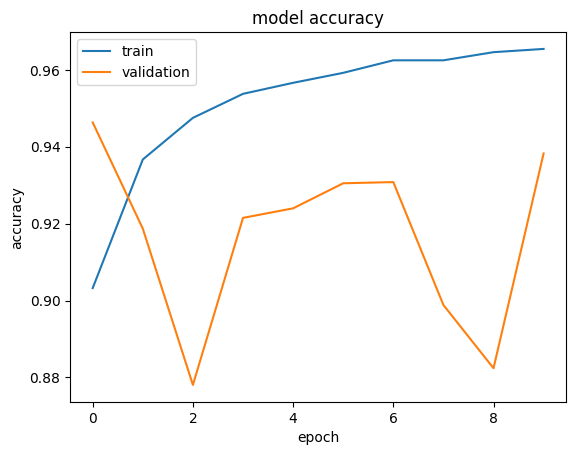

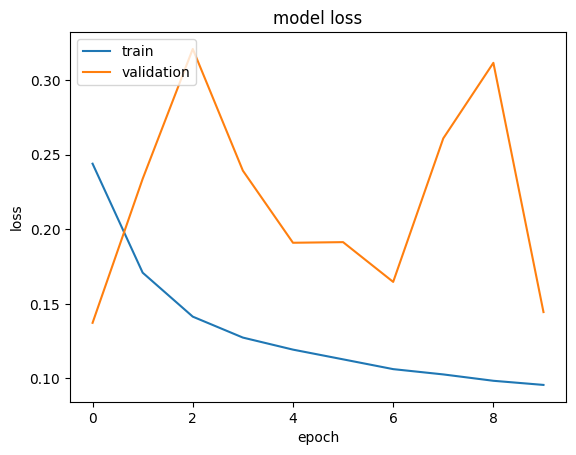

In [ ]:
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential, Model
from keras.optimizers import RMSprop
from keras.layers import Activation, Dropout, Flatten, Dense, GlobalMaxPooling2D, Conv2D, MaxPooling2D
from keras.callbacks import CSVLogger
from sklearn.model_selection import train_test_split


# Taking Path Files for Training and Testing
path = '/content/data/data'
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
print(train_dir)
print(test_dir)
print(os.listdir(train_dir))

# Hyperparams
IMAGE_SIZE = 128
IMAGE_WIDTH, IMAGE_HEIGHT = IMAGE_SIZE, IMAGE_SIZE
EPOCHS = 10
BATCH_SIZE = 16

input_shape = (IMAGE_WIDTH, IMAGE_HEIGHT, 3)

# data generators
training_data_generator = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

validation_data_generator = ImageDataGenerator(rescale=1./255)
# Data preparation

training_generator = training_data_generator.flow_from_directory(
    train_dir,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="binary")
validation_generator = validation_data_generator.flow_from_directory(
    test_dir,
    target_size=(IMAGE_WIDTH, IMAGE_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="binary")


sample, label = next(validation_generator)
print(sample[0])
print(label[0])

# model
# model
model = Sequential()

model.add(Conv2D(16, 3, input_shape=input_shape, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(16, 3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())

model.add(Dropout(0.7))
model.add(Dense(16, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation = 'sigmoid'))

# model.add(Activation('sigmoid'))
model.summary()
# compile model

model.compile(loss='binary_crossentropy',
            optimizer='adam',
            metrics=['accuracy'])

print(len(training_generator.filenames))
# train model

history=model.fit(
    training_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
)


model.save('/content/drive/MyDrive/models/Drowsiness_model.h5')
 #   validation_steps=len(validation_generator.filenames) // BATCH_SIZE

model = tf.keras.models.load_model('/content/drive/MyDrive/models/Drowsiness_model.h5')


sample1, label1 = next(validation_generator)
predictions = model.predict(sample1)
print(predictions)


def check_results():
   class_names = [ 'Open_Eyes', 'Closed_Eyes']
   sample1, label1 = next(validation_generator)
   predictions = model.predict(sample1)
   for num in range(len(predictions)):
       if predictions[num] > 0.5:
           print('prediction: '+'Closed_Eyes'+' ' + str(int(predictions[num]*100))+ '%')
       else:
           print('prediction: '+'Open_Eyes'+' ' + str(100- int(predictions[num]*100))+ '%')

       print('actual: '+ class_names[int(label1[num])])
       plt.imshow(sample1[num])
       plt.show()

#check_results()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


**Install the face recoginiton and playing sound libraries to detect face for predciting if the eyes are closed or open.**

In [ ]:
loss, accuracy = model.evaluate(validation_generator)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

202/202 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9383 - loss: 0.1444
Test Loss: 0.1444493979215622
Test Accuracy: 0.9382562637329102


In [ ]:
!pip install playsound
#!pip install -U PyObjC
!pip install face_recognition
!pip install -U tensorboard_plugin_profile

  Preparing metadata (setup.py) ... done
  Created wheel for playsound: filename=playsound-1.3.0-py3-none-any.whl size=7020 sha256=1c5e89c7e6245778ec31bc8e89183df48969cca6974927daee17ef36ac3df94e
  Stored in directory: /root/.cache/pip/wheels/cf/42/ff/7c587bae55eec67b909ca316b250d9b4daedbf272a3cbeb907
Successfully built playsound
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=7d52c3ad106f93baa26f36a2fc5fc1ee2fb371de0438b5bf7fac6c4aa084f6ab
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.9/25.9 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 14.9 MB/s eta 0:00:00




1.   We will run face recognition library to detect the face
2. Then use some conditions to detect the eyes on the face to see if the eyes are open or closed.
3. After predicting we will make some boxes to tell if the camera is active or not and if the driver is sleeping or not.
4. If the driver is sleeping for 3 or more frames a box will appearing saying driver is sleeping.
5. You can also play a sound to wake him up.



In [ ]:
pip install opencv-python face-recognition tensorflow playsound pillow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

CPU_Pct=str(round(float(os.popen('''grep 'cpu ' /proc/stat | awk '{usage=($2+$4)*100/($2+$4+$5)} END {print usage }' ''').readline()),2))
print("CPU Usage = " + CPU_Pct)  # print results


CPU Usage = 12.36


In [ ]:
import psutil
pid = os.getpid()
python_process = psutil.Process(pid)
memoryUse = python_process.memory_info()[0]/2.**30  # memory use in GB...I think
print('memory use:', memoryUse)

memory use: 0.1161956787109375
